# V2 Modeling

In [1]:
# ==========
# 0. 패키지
# ==========

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

In [2]:
# ===============
# 1. 데이터 로드
# ===============
train = pd.read_csv("train_V2.csv")
test = pd.read_csv("test_V2.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

TARGET = "fraud"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
X_test = test.copy()

print("Fraud rate:", y.mean())

train shape: (18000, 93)
test shape : (12000, 92)
Fraud rate: 0.1582222222222222


In [3]:
# ===========
# 2. CV 설정
# ===========
N_SPLITS = 5
RANDOM_STATE = 2542

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [4]:
# ==========================================
# 3. LightGBM 파라미터
# ------------------------------------------
# 불균형 데이터이므로 scale_pos_weight 반영
# ==========================================
pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = neg / pos

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.5,
    "n_estimators": 10000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
}

In [5]:
# ===================
# 4. Fold 반복 학습
# ===================
# 결과 저장 변수
oof_pred = np.zeros(len(X))
oof_pred_label = np.zeros(len(X), dtype=int)
test_pred = np.zeros(len(X_test))

fold_scores = []
feature_importance_list = []
models = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    # 클래스 불균형 반영
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = lgb.LGBMClassifier(**params)

    fit_kwargs = dict(
        X=X_train,
        y=y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=300),
            lgb.log_evaluation(period=200)
        ]
    )

    model.fit(**fit_kwargs)

    # validation prediction
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred_label = (valid_pred_proba >= 0.5).astype(int)

    # OOF 저장
    oof_pred[valid_idx] = valid_pred_proba
    oof_pred_label[valid_idx] = valid_pred_label

    # test prediction 저장
    test_pred += model.predict_proba(X_test)[:, 1] / N_SPLITS

    # fold metric
    fold_auc = roc_auc_score(y_valid, valid_pred_proba)
    fold_pr_auc = average_precision_score(y_valid, valid_pred_proba)
    fold_f1 = f1_score(y_valid, valid_pred_label, zero_division=0)

    print(f"Fold {fold} ROC-AUC : {fold_auc:.4f}")
    print(f"Fold {fold} PR-AUC  : {fold_pr_auc:.4f}")
    print(f"Fold {fold} F1      : {fold_f1:.4f}")

    fold_scores.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "pr_auc": fold_pr_auc,
        "f1": fold_f1
    })

    # feature importance 저장
    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
        "fold": fold
    })
    feature_importance_list.append(fold_importance)

    models.append(model)


==================== Fold 1 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.679508
[400]	valid_0's auc: 0.676883
Early stopping, best iteration is:
[102]	valid_0's auc: 0.683409
Fold 1 ROC-AUC : 0.6834
Fold 1 PR-AUC  : 0.2773
Fold 1 F1      : 0.3505

==================== Fold 2 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.703285
[400]	valid_0's auc: 0.691553
Early stopping, best iteration is:
[159]	valid_0's auc: 0.708948
Fold 2 ROC-AUC : 0.7089
Fold 2 PR-AUC  : 0.3137
Fold 2 F1      : 0.3585

==================== Fold 3 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.679943
Early stopping, best iteration is:
[96]	valid_0's auc: 0.686212
Fold 3 ROC-AUC : 0.6862
Fold 3 PR-AUC  : 0.2719
Fold 3 F1      : 0.3504

==================== Fold 4 ====================
Training until validation scores don't improve for 300

In [6]:
# ==================
# 6. Fold 결과 요약
# ==================
score_df = pd.DataFrame(fold_scores)

print("\n========== Fold Scores ==========")
print(score_df)

print("\n========== CV Mean Scores ==========")
print(f"Mean ROC-AUC : {score_df['roc_auc'].mean():.4f}")
print(f"Std  ROC-AUC : {score_df['roc_auc'].std():.4f}")
print(f"Mean PR-AUC  : {score_df['pr_auc'].mean():.4f}")
print(f"Mean F1      : {score_df['f1'].mean():.4f}")


========== Fold Scores ==========
   fold   roc_auc    pr_auc        f1
0     1  0.683409  0.277259  0.350453
1     2  0.708948  0.313684  0.358503
2     3  0.686212  0.271876  0.350356
3     4  0.691398  0.286992  0.350832
4     5  0.699342  0.286359  0.354180

========== CV Mean Scores ==========
Mean ROC-AUC : 0.6939
Std  ROC-AUC : 0.0104
Mean PR-AUC  : 0.2872
Mean F1      : 0.3529


In [7]:
# ===========================
# 5. 전체 OOF 기준 성능 평가
# ===========================
oof_auc = roc_auc_score(y, oof_pred)
oof_pr_auc = average_precision_score(y, oof_pred)
oof_f1 = f1_score(y, oof_pred_label, zero_division=0)

print("\n========== OOF Overall Performance ==========")
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")
print(f"OOF F1      : {oof_f1:.4f}")

print("\n========== OOF Confusion Matrix ==========")
print(confusion_matrix(y, oof_pred_label))

print("\n========== OOF Classification Report ==========")
print(classification_report(y, oof_pred_label, digits=4, zero_division=0))


========== OOF Overall Performance ==========
OOF ROC-AUC : 0.6937
OOF PR-AUC  : 0.2855
OOF F1      : 0.3528

========== OOF Confusion Matrix ==========
[[11492  3660]
 [ 1454  1394]]

========== OOF Classification Report ==========
              precision    recall  f1-score   support

         0.0     0.8877    0.7584    0.8180     15152
         1.0     0.2758    0.4895    0.3528      2848

    accuracy                         0.7159     18000
   macro avg     0.5818    0.6240    0.5854     18000
weighted avg     0.7909    0.7159    0.7444     18000



In [8]:
# ===========================
# 6. 평균 Feature Importance
# ===========================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance ==========")
print(mean_importance.head(20))


========== Mean Feature Importance ==========
                      feature  importance
0               age_of_driver       453.6
1          zip_fraud_rate_oof       436.6
2                   liab_prct       409.8
3              vehicle_weight       400.2
4               annual_income       363.0
5                safty_rating       351.8
6            price_per_weight       337.2
7     vehicle_to_income_ratio       331.6
8   income_safety_interaction       329.4
9                   claim_day       299.0
10   estimated_residual_value       208.8
11              vehicle_price       173.8
12           claim_est_payout       150.6
13         past_num_of_claims       148.0
14                claim_month       137.8
15   payout_to_residual_ratio       136.8
16     payout_to_income_ratio       133.8
17                  month_cos       132.4
18       composite_risk_score       117.8
19      payout_to_price_ratio       115.4


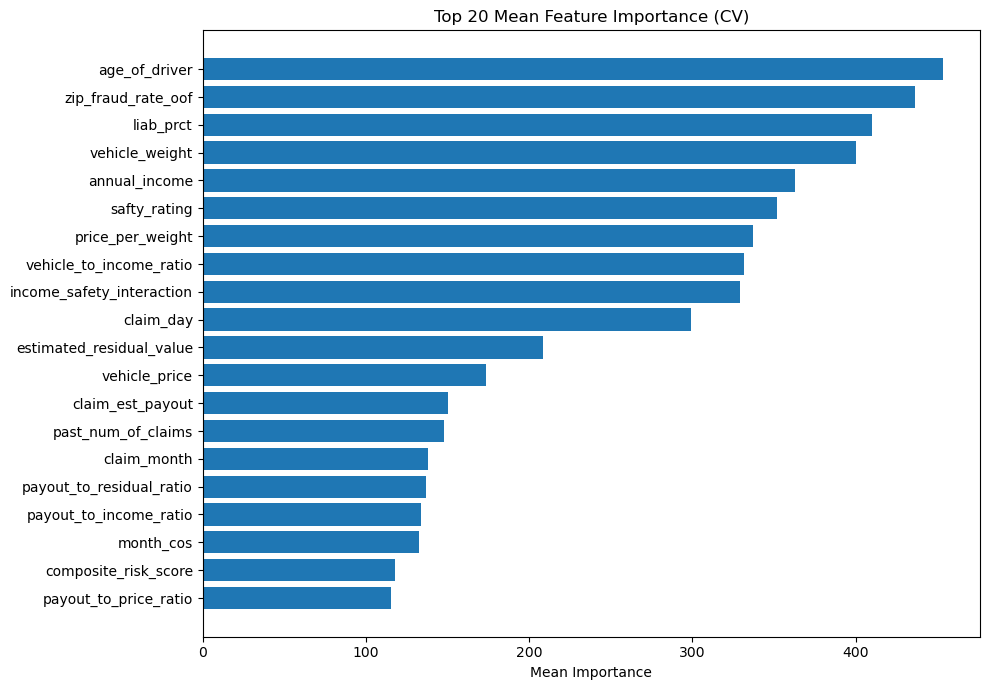

In [9]:
# =============================
# 7. Feature Importance 시각화
# =============================
top_k = 20

plt.figure(figsize=(10, 7))
plt.barh(
    mean_importance["feature"].head(top_k)[::-1],
    mean_importance["importance"].head(top_k)[::-1]
)
plt.title("Top 20 Mean Feature Importance (CV)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [10]:
# ====================
# 8. Threshold Tuning
# ====================
threshold_list = np.arange(0.05, 0.51, 0.05)

result_list = []

print("========== Threshold Tuning ==========")

for th in threshold_list:
    pred_label = (oof_pred >= th).astype(int)

    f1 = f1_score(y, pred_label, zero_division=0)
    precision = precision_score(y, pred_label, zero_division=0)
    recall = recall_score(y, pred_label, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y, pred_label).ravel()

    result_list.append({
        "threshold": th,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

    print(f"\nThreshold = {th:.2f}")
    print(f"F1        : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

result_df = pd.DataFrame(result_list)

========== Threshold Tuning ==========

Threshold = 0.05
F1        : 0.2765
Precision : 0.1604
Recall    : 0.9993
TP=2846 FP=14893 FN=2 TN=259

Threshold = 0.10
F1        : 0.2883
Precision : 0.1686
Recall    : 0.9951
TP=2834 FP=13975 FN=14 TN=1177

Threshold = 0.15
F1        : 0.3002
Precision : 0.1771
Recall    : 0.9846
TP=2804 FP=13028 FN=44 TN=2124

Threshold = 0.20
F1        : 0.3116
Precision : 0.1861
Recall    : 0.9575
TP=2727 FP=11930 FN=121 TN=3222

Threshold = 0.25
F1        : 0.3212
Precision : 0.1950
Recall    : 0.9098
TP=2591 FP=10693 FN=257 TN=4459

Threshold = 0.30
F1        : 0.3315
Precision : 0.2057
Recall    : 0.8543
TP=2433 FP=9396 FN=415 TN=5756

Threshold = 0.35
F1        : 0.3438
Precision : 0.2198
Recall    : 0.7890
TP=2247 FP=7977 FN=601 TN=7175

Threshold = 0.40
F1        : 0.3549
Precision : 0.2363
Recall    : 0.7131
TP=2031 FP=6565 FN=817 TN=8587

Threshold = 0.45
F1        : 0.3593
Precision : 0.2544
Recall    : 0.6113
TP=1741 FP=5102 FN=1107 TN=10050

Thre

In [11]:
# ===================
# 9. Best Threshold
# ===================
best_row = result_df.loc[result_df["f1"].idxmax()]

print("\n========== Best Threshold ==========")
print(best_row)


========== Best Threshold ==========
threshold        0.450000
f1               0.359302
precision        0.254421
recall           0.611306
tp            1741.000000
fp            5102.000000
fn            1107.000000
tn           10050.000000
Name: 8, dtype: float64


In [12]:
# =====================
# 10. Recall@TopK 함수
# =====================
def recall_at_k(y_true, pred_prob, k_ratio=0.1):
    k = int(len(pred_prob) * k_ratio)
    top_idx = np.argsort(pred_prob)[::-1][:k]
    recall = y_true.iloc[top_idx].sum() / y_true.sum()
    return recall

In [13]:
# ======================
# 11. Recall@TopK 출력
# ======================
k_list = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

print("\n========== Recall@TopK ==========")
for k in k_list:
    recall_k = recall_at_k(y, oof_pred, k_ratio=k)
    print(f"Recall@Top{int(k*100)}%: {recall_k:.4f}")


========== Recall@TopK ==========
Recall@Top1%: 0.0295
Recall@Top3%: 0.0755
Recall@Top5%: 0.1229
Recall@Top10%: 0.2156
Recall@Top20%: 0.3792
Recall@Top30%: 0.5109
